# 🏦 FinGuard AI — Risk Engine

**Notebook:** 09 — Risk Engine

#### Objective
Build the decision layer that combines the supervised fraud probability from the optimized fraud model with the anomaly signal produced by Isolation Forest.

#### Risk Pipeline

**Transaction Features → Fraud Probability + Anomaly Score → Risk Score → Risk Level → Decision**

The Risk Engine is the bridge between model outputs and the application layer.


#### 1. Environment Setup

In [1]:
import sys
import warnings
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

print("FinGuard AI — Risk Engine")
print("=" * 70)
print("Python :", sys.version.split()[0])
print("NumPy  :", np.__version__)
print("Pandas :", pd.__version__)


FinGuard AI — Risk Engine
Python : 3.11.15
NumPy  : 2.4.6
Pandas : 3.0.5


#### 2. Project Paths

In [2]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "Notebooks" else NOTEBOOK_DIR

PROCESSED_DIR = PROJECT_ROOT / "Dataset" / "Processed"
MODEL_DIR = PROJECT_ROOT / "Models"
ANOMALY_MODEL_DIR = MODEL_DIR / "anomaly_model"
REPORT_DIR = PROJECT_ROOT / "Reports"
MODEL_EVAL_DIR = REPORT_DIR / "Model_Evaluation"
FIGURES_DIR = REPORT_DIR / "Figures"

MODEL_EVAL_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TEST_PATH = PROCESSED_DIR / "feature_engineered_test.csv"

# Supervised model generated by the previous stages.
MODEL_CANDIDATES = [
    MODEL_DIR / "optimized_fraud_model.joblib",
    MODEL_DIR / "best_fraud_model.joblib",
    MODEL_DIR / "xgboost_model.joblib"
]

FRAUD_MODEL_PATH = next((p for p in MODEL_CANDIDATES if p.exists()), None)

THRESHOLD_PATH = MODEL_DIR / "fraud_threshold_metadata.joblib"
MODEL_METADATA_PATH = MODEL_DIR / "final_model_metadata.joblib"

ANOMALY_MODEL_PATH = ANOMALY_MODEL_DIR / "isolation_forest.pkl"
ANOMALY_METADATA_PATH = ANOMALY_MODEL_DIR / "isolation_forest_metadata.pkl"

ANOMALY_RESULTS_PATH = MODEL_EVAL_DIR / "anomaly_detection_results.csv"

RISK_RESULTS_PATH = MODEL_EVAL_DIR / "risk_engine_results.csv"
RISK_SUMMARY_PATH = MODEL_EVAL_DIR / "risk_engine_summary.csv"
RISK_METADATA_PATH = MODEL_DIR / "risk_engine_metadata.joblib"

print("Project Root      :", PROJECT_ROOT)
print("Test Data         :", TEST_PATH)
print("Fraud Model       :", FRAUD_MODEL_PATH)
print("Fraud Threshold   :", THRESHOLD_PATH)
print("Anomaly Model     :", ANOMALY_MODEL_PATH)
print("Anomaly Results   :", ANOMALY_RESULTS_PATH)


Project Root      : C:\Users\viqua\Desktop\FinGuard AI
Test Data         : C:\Users\viqua\Desktop\FinGuard AI\Dataset\Processed\feature_engineered_test.csv
Fraud Model       : C:\Users\viqua\Desktop\FinGuard AI\Models\optimized_fraud_model.joblib
Fraud Threshold   : C:\Users\viqua\Desktop\FinGuard AI\Models\fraud_threshold_metadata.joblib
Anomaly Model     : C:\Users\viqua\Desktop\FinGuard AI\Models\anomaly_model\isolation_forest.pkl
Anomaly Results   : C:\Users\viqua\Desktop\FinGuard AI\Reports\Model_Evaluation\anomaly_detection_results.csv


#### 3. Validate Required Artifacts

In [3]:
required = {
    "Test Dataset": TEST_PATH,
    "Fraud Model": FRAUD_MODEL_PATH,
    "Anomaly Model": ANOMALY_MODEL_PATH,
    "Anomaly Metadata": ANOMALY_METADATA_PATH,
    "Anomaly Results": ANOMALY_RESULTS_PATH
}

for name, path in required.items():
    print(("✓ EXISTS" if path is not None and Path(path).exists() else "✗ MISSING").ljust(12), name, ":", path)

missing = [name for name, path in required.items() if path is None or not Path(path).exists()]
if missing:
    raise FileNotFoundError(f"Required Risk Engine artifacts are missing: {missing}")

print("\n✓ Required artifact validation passed")


✓ EXISTS     Test Dataset : C:\Users\viqua\Desktop\FinGuard AI\Dataset\Processed\feature_engineered_test.csv
✓ EXISTS     Fraud Model : C:\Users\viqua\Desktop\FinGuard AI\Models\optimized_fraud_model.joblib
✓ EXISTS     Anomaly Model : C:\Users\viqua\Desktop\FinGuard AI\Models\anomaly_model\isolation_forest.pkl
✓ EXISTS     Anomaly Metadata : C:\Users\viqua\Desktop\FinGuard AI\Models\anomaly_model\isolation_forest_metadata.pkl
✓ EXISTS     Anomaly Results : C:\Users\viqua\Desktop\FinGuard AI\Reports\Model_Evaluation\anomaly_detection_results.csv

✓ Required artifact validation passed


#### 4. Load Test Data and Models

In [4]:
test_df = pd.read_csv(TEST_PATH)

fraud_model = joblib.load(FRAUD_MODEL_PATH)
anomaly_model = joblib.load(ANOMALY_MODEL_PATH)
anomaly_metadata = joblib.load(ANOMALY_METADATA_PATH)

print("✓ Test dataset loaded:", test_df.shape)
print("✓ Fraud model loaded :", type(fraud_model).__name__)
print("✓ Anomaly model loaded:", type(anomaly_model).__name__)


✓ Test dataset loaded: (56746, 54)
✓ Fraud model loaded : XGBClassifier
✓ Anomaly model loaded: IsolationForest


#### 5. Determine Feature Order

In [5]:
TARGET = "Class"

if TARGET not in test_df.columns:
    raise KeyError(f"Target column '{TARGET}' not found in test dataset.")

if isinstance(anomaly_metadata, dict) and anomaly_metadata.get("feature_columns"):
    feature_columns = list(anomaly_metadata["feature_columns"])
else:
    feature_columns = [c for c in test_df.columns if c != TARGET]

missing_features = [c for c in feature_columns if c not in test_df.columns]
if missing_features:
    raise ValueError(f"Missing model features: {missing_features[:20]}")

X_test = test_df[feature_columns].copy()
y_test = test_df[TARGET].astype(int).copy()

if X_test.isnull().any().any():
    raise ValueError("Missing values detected in Risk Engine feature matrix.")

if np.isinf(X_test.to_numpy()).any():
    raise ValueError("Infinite values detected in Risk Engine feature matrix.")

print("Target  :", TARGET)
print("Features:", len(feature_columns))
print("Samples :", len(X_test))


Target  : Class
Features: 53
Samples : 56746


#### 6. Load the Selected Fraud Threshold

The threshold is read from the saved artifact when available. If the metadata file is not present or does not contain a usable threshold, the notebook uses the deployment threshold already established in Notebook 07: **0.82**.


In [6]:
def extract_threshold(obj):
    if isinstance(obj, (int, float, np.integer, np.floating)):
        return float(obj)

    if isinstance(obj, dict):
        preferred_keys = [
            "threshold",
            "fraud_threshold",
            "selected_threshold",
            "best_threshold",
            "optimal_threshold"
        ]
        for key in preferred_keys:
            value = obj.get(key)
            if isinstance(value, (int, float, np.integer, np.floating)):
                return float(value)

        for value in obj.values():
            if isinstance(value, (int, float, np.integer, np.floating)):
                candidate = float(value)
                if 0 < candidate < 1:
                    return candidate

    return None

threshold = None

if THRESHOLD_PATH.exists():
    threshold_metadata = joblib.load(THRESHOLD_PATH)
    threshold = extract_threshold(threshold_metadata)

if threshold is None:
    threshold = 0.82
    threshold_source = "Notebook 07 deployment threshold fallback"
else:
    threshold_source = str(THRESHOLD_PATH)

if not 0 < threshold < 1:
    raise ValueError(f"Invalid fraud threshold: {threshold}")

print(f"✓ Fraud threshold: {threshold:.6f}")
print(f"✓ Source         : {threshold_source}")


✓ Fraud threshold: 0.820000
✓ Source         : C:\Users\viqua\Desktop\FinGuard AI\Models\fraud_threshold_metadata.joblib


#### 7. Generate Supervised Fraud Probability

In [7]:
if not hasattr(fraud_model, "predict_proba"):
    raise TypeError("The selected fraud model does not expose predict_proba().")

start = time.time()

fraud_probabilities = fraud_model.predict_proba(X_test)[:, 1]

fraud_prediction = (fraud_probabilities >= threshold).astype(int)

fraud_prediction_time = time.time() - start

print(f"✓ Fraud probabilities generated in {fraud_prediction_time:.3f} seconds")
print(f"Probability range: {fraud_probabilities.min():.6f} → {fraud_probabilities.max():.6f}")
print(f"Predicted fraud  : {fraud_prediction.sum():,}")


✓ Fraud probabilities generated in 0.360 seconds
Probability range: 0.000000 → 1.000000
Predicted fraud  : 82


#### 8. Generate Anomaly Signal

In [8]:
anomaly_raw = anomaly_model.predict(X_test)
anomaly_label = np.where(anomaly_raw == -1, 1, 0)

# Isolation Forest decision_function:
# higher = more normal, therefore negate it for anomaly severity.
raw_anomaly_score = -anomaly_model.decision_function(X_test)

score_min = raw_anomaly_score.min()
score_max = raw_anomaly_score.max()

if score_max > score_min:
    anomaly_score_100 = (
        (raw_anomaly_score - score_min) /
        (score_max - score_min)
    ) * 100
else:
    anomaly_score_100 = np.zeros(len(X_test))

print("✓ Anomaly signal generated")
print(f"Detected anomalies: {anomaly_label.sum():,}")
print(f"Anomaly score range: {anomaly_score_100.min():.2f} → {anomaly_score_100.max():.2f}")


✓ Anomaly signal generated
Detected anomalies: 71
Anomaly score range: 0.00 → 100.00


#### 9. Risk Score Design

The Risk Engine uses a transparent weighted score:

- **70% — supervised fraud probability**
- **30% — anomaly severity**

Both signals are represented on a 0–100 scale before combination.

This keeps the supervised fraud model as the primary decision signal while allowing unusual transaction behaviour to increase risk.

##### Risk Bands

- **0–39.99 → Low**
- **40–69.99 → Medium**
- **70–100 → High**


In [9]:
fraud_score_100 = fraud_probabilities * 100

FRAUD_WEIGHT = 0.70
ANOMALY_WEIGHT = 0.30

risk_score = (
    FRAUD_WEIGHT * fraud_score_100 +
    ANOMALY_WEIGHT * anomaly_score_100
)

risk_score = np.clip(risk_score, 0, 100)

risk_level = np.select(
    [
        risk_score >= 70,
        risk_score >= 40
    ],
    [
        "High",
        "Medium"
    ],
    default="Low"
)

print("✓ Risk score generated")
print(f"Fraud signal weight   : {FRAUD_WEIGHT:.0%}")
print(f"Anomaly signal weight : {ANOMALY_WEIGHT:.0%}")
print("\nRisk level distribution:")
print(pd.Series(risk_level).value_counts().reindex(["Low", "Medium", "High"], fill_value=0))


✓ Risk score generated
Fraud signal weight   : 70%
Anomaly signal weight : 30%

Risk level distribution:
Low       56644
Medium       23
High         79
Name: count, dtype: int64


#### 10. Final Risk Decision

The application-facing decision is derived from the risk score and the fraud threshold.

- High risk → **Block / Review**
- Medium risk → **Review**
- Low risk → **Allow**

The supervised fraud prediction is retained separately so downstream applications can inspect both the model decision and the broader risk decision.


In [10]:
risk_decision = np.select(
    [
        risk_level == "High",
        risk_level == "Medium"
    ],
    [
        "Block / Review",
        "Review"
    ],
    default="Allow"
)

risk_results = pd.DataFrame({
    "Actual_Class": y_test.to_numpy(),
    "Fraud_Probability": fraud_probabilities,
    "Fraud_Score_100": fraud_score_100,
    "Fraud_Prediction": fraud_prediction,
    "Anomaly_Label": anomaly_label,
    "Anomaly_Score_100": anomaly_score_100,
    "Risk_Score": risk_score,
    "Risk_Level": risk_level,
    "Risk_Decision": risk_decision
})

display(risk_results.head(10))


,Actual_Class,Fraud_Probability,Fraud_Score_100,Fraud_Prediction,Anomaly_Label,Anomaly_Score_100,Risk_Score,Risk_Level,Risk_Decision
0,0,4.720925e-06,0.000472,0,0,6.934286,2.080616,Low,Allow
1,0,6.721923e-06,0.000672,0,0,6.976506,2.093422,Low,Allow
2,0,1.282017e-05,0.001282,0,0,17.221694,5.167406,Low,Allow
3,0,3.779262e-06,0.000378,0,0,5.154088,1.546491,Low,Allow
4,0,2.687612e-04,0.026876,0,0,7.653125,2.314751,Low,Allow
5,0,1.532890e-04,0.015329,0,0,6.568003,1.981131,Low,Allow
6,0,4.144535e-06,0.000414,0,0,14.404069,4.321511,Low,Allow
7,0,9.110456e-08,0.000009,0,0,17.591548,5.277471,Low,Allow
8,0,2.563596e-04,0.025636,0,0,13.990082,4.214970,Low,Allow
9,0,7.476905e-06,0.000748,0,0,6.890897,2.067793,Low,Allow


#### 11. Risk Engine Summary

In [11]:
risk_counts = risk_results["Risk_Level"].value_counts()

summary = pd.DataFrame([{
    "Total_Transactions": len(risk_results),
    "Low_Risk": int(risk_counts.get("Low", 0)),
    "Medium_Risk": int(risk_counts.get("Medium", 0)),
    "High_Risk": int(risk_counts.get("High", 0)),
    "Predicted_Fraud": int(fraud_prediction.sum()),
    "Detected_Anomalies": int(anomaly_label.sum()),
    "Mean_Fraud_Probability": float(fraud_probabilities.mean()),
    "Mean_Anomaly_Score": float(anomaly_score_100.mean()),
    "Mean_Risk_Score": float(risk_score.mean()),
    "Fraud_Weight": FRAUD_WEIGHT,
    "Anomaly_Weight": ANOMALY_WEIGHT,
    "Fraud_Threshold": threshold
}])

display(summary)


,Total_Transactions,Low_Risk,Medium_Risk,High_Risk,Predicted_Fraud,Detected_Anomalies,Mean_Fraud_Probability,Mean_Anomaly_Score,Mean_Risk_Score,Fraud_Weight,Anomaly_Weight,Fraud_Threshold
0,56746,56644,23,79,82,71,0.002081,11.552043,3.611286,0.7,0.3,0.82


#### 12. Risk Level Distribution

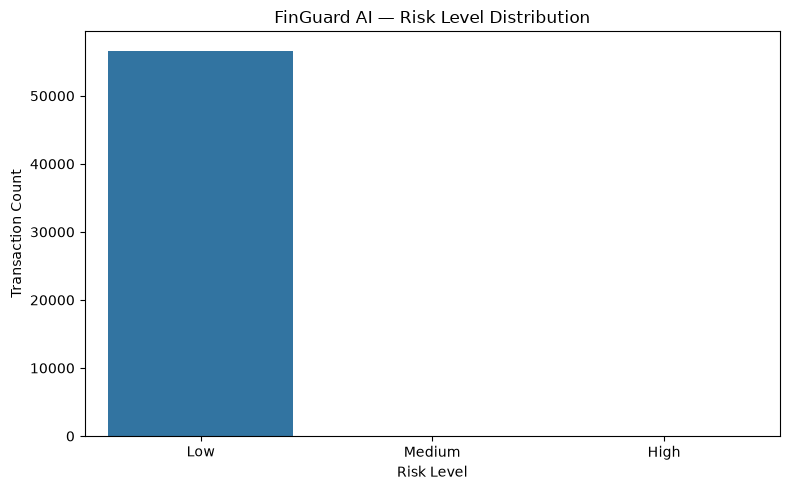

In [12]:
risk_order = ["Low", "Medium", "High"]

plt.figure(figsize=(8, 5))
sns.countplot(
    data=risk_results,
    x="Risk_Level",
    order=risk_order
)
plt.xlabel("Risk Level")
plt.ylabel("Transaction Count")
plt.title("FinGuard AI — Risk Level Distribution")
plt.tight_layout()
plt.show()


#### 13. Fraud Probability vs Anomaly Score

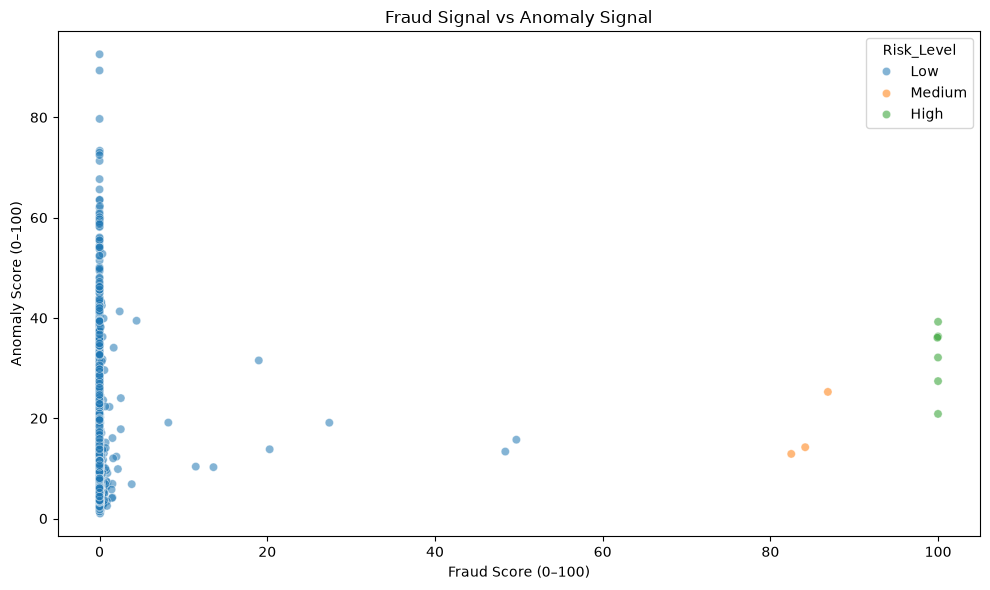

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=risk_results.sample(
        min(5000, len(risk_results)),
        random_state=42
    ),
    x="Fraud_Score_100",
    y="Anomaly_Score_100",
    hue="Risk_Level",
    hue_order=["Low", "Medium", "High"],
    alpha=0.55
)
plt.xlabel("Fraud Score (0–100)")
plt.ylabel("Anomaly Score (0–100)")
plt.title("Fraud Signal vs Anomaly Signal")
plt.tight_layout()
plt.show()


#### 14. Risk Score Distribution

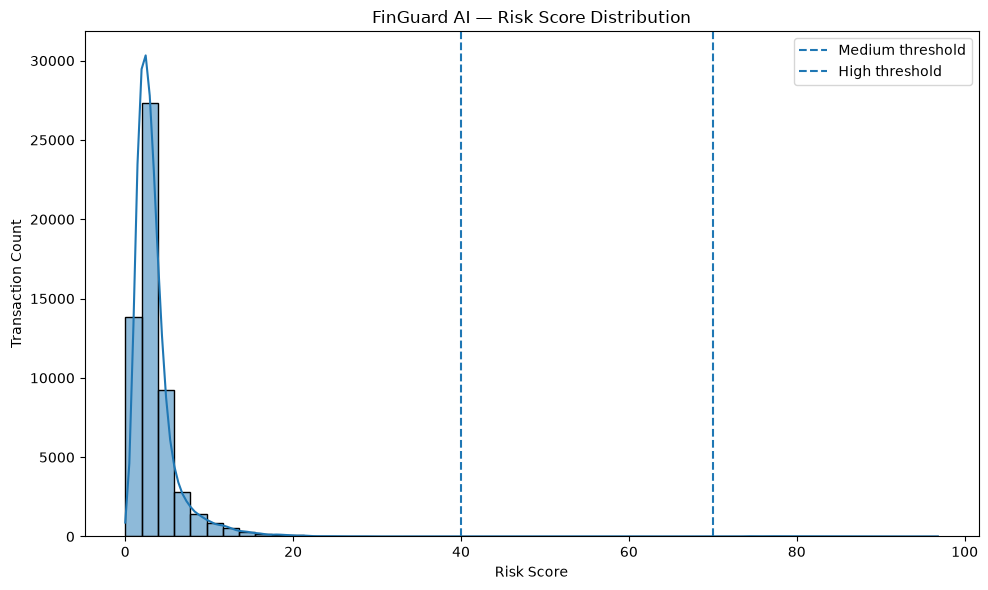

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(
    risk_results["Risk_Score"],
    bins=50,
    kde=True
)
plt.axvline(40, linestyle="--", label="Medium threshold")
plt.axvline(70, linestyle="--", label="High threshold")
plt.xlabel("Risk Score")
plt.ylabel("Transaction Count")
plt.title("FinGuard AI — Risk Score Distribution")
plt.legend()
plt.tight_layout()
plt.show()


#### 15. High-Risk Transactions

In [15]:
high_risk = risk_results[
    risk_results["Risk_Level"] == "High"
].sort_values("Risk_Score", ascending=False)

print(f"High-risk transactions: {len(high_risk):,}")
display(high_risk.head(25))


High-risk transactions: 79


,Actual_Class,Fraud_Probability,Fraud_Score_100,Fraud_Prediction,Anomaly_Label,Anomaly_Score_100,Risk_Score,Risk_Level,Risk_Decision
8671,1,0.999565,99.956505,1,1,89.490769,96.816782,High,Block / Review
17342,1,0.999981,99.998131,1,1,82.160575,94.646860,High,Block / Review
26366,1,0.999998,99.999847,1,0,64.742137,89.422534,High,Block / Review
30966,1,0.999994,99.999382,1,0,56.756057,87.026382,High,Block / Review
32082,1,0.999990,99.998962,1,0,56.280017,86.883280,High,Block / Review
41761,1,0.999994,99.999428,1,0,54.962433,86.488326,High,Block / Review
52638,1,0.999997,99.999748,1,0,54.395233,86.318395,High,Block / Review
50640,1,0.999969,99.996933,1,0,54.341216,86.300213,High,Block / Review
1339,1,0.999939,99.993858,1,0,53.963954,86.184883,High,Block / Review
36755,1,0.999996,99.999580,1,0,53.339347,86.001507,High,Block / Review


#### 16. Risk Engine Evaluation Against Actual Fraud

In [16]:
# The Risk Engine is a decision layer rather than a replacement classifier.
# Still, its high-risk flag can be evaluated against the held-out labels.

risk_pred = (risk_results["Risk_Level"] == "High").astype(int)

risk_accuracy = accuracy_score(y_test, risk_pred)
risk_precision = precision_score(y_test, risk_pred, zero_division=0)
risk_recall = recall_score(y_test, risk_pred, zero_division=0)
risk_f1 = f1_score(y_test, risk_pred, zero_division=0)

print("Risk Engine — High-Risk Classification")
print("=" * 55)
print(f"Accuracy : {risk_accuracy:.4f}")
print(f"Precision: {risk_precision:.4f}")
print(f"Recall   : {risk_recall:.4f}")
print(f"F1-score : {risk_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        risk_pred,
        target_names=["Legitimate", "Fraud"],
        zero_division=0
    )
)

try:
    risk_roc_auc = roc_auc_score(y_test, risk_results["Risk_Score"])
    risk_pr_auc = average_precision_score(y_test, risk_results["Risk_Score"])
    print(f"ROC-AUC  : {risk_roc_auc:.4f}")
    print(f"PR-AUC   : {risk_pr_auc:.4f}")
except ValueError:
    risk_roc_auc = np.nan
    risk_pr_auc = np.nan


Risk Engine — High-Risk Classification
Accuracy : 0.9995
Precision: 0.9241
Recall   : 0.7684
F1-score : 0.8391

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.92      0.77      0.84        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC  : 0.9501
PR-AUC   : 0.7961


#### 17. Risk Confusion Matrix

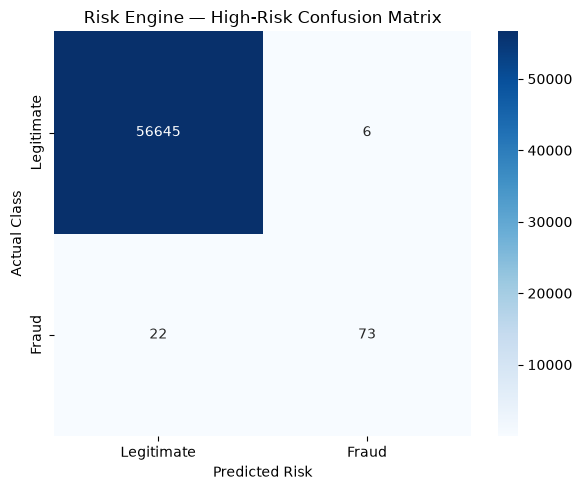

In [17]:
cm = confusion_matrix(y_test, risk_pred, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)
plt.xlabel("Predicted Risk")
plt.ylabel("Actual Class")
plt.title("Risk Engine — High-Risk Confusion Matrix")
plt.tight_layout()
plt.show()


#### 18. Risk Priority Queue

In [18]:
priority_queue = risk_results.copy()

priority_queue["Priority"] = np.select(
    [
        priority_queue["Risk_Level"] == "High",
        priority_queue["Risk_Level"] == "Medium"
    ],
    [
        1,
        2
    ],
    default=3
)

priority_queue = priority_queue.sort_values(
    ["Priority", "Risk_Score"],
    ascending=[True, False]
).reset_index(drop=True)

display(priority_queue.head(50))


,Actual_Class,Fraud_Probability,Fraud_Score_100,Fraud_Prediction,Anomaly_Label,Anomaly_Score_100,Risk_Score,Risk_Level,Risk_Decision,Priority
0,1,0.999565,99.956505,1,1,89.490769,96.816782,High,Block / Review,1
1,1,0.999981,99.998131,1,1,82.160575,94.646860,High,Block / Review,1
2,1,0.999998,99.999847,1,0,64.742137,89.422534,High,Block / Review,1
3,1,0.999994,99.999382,1,0,56.756057,87.026382,High,Block / Review,1
4,1,0.999990,99.998962,1,0,56.280017,86.883280,High,Block / Review,1
5,1,0.999994,99.999428,1,0,54.962433,86.488326,High,Block / Review,1
6,1,0.999997,99.999748,1,0,54.395233,86.318395,High,Block / Review,1
7,1,0.999969,99.996933,1,0,54.341216,86.300213,High,Block / Review,1
8,1,0.999939,99.993858,1,0,53.963954,86.184883,High,Block / Review,1
9,1,0.999996,99.999580,1,0,53.339347,86.001507,High,Block / Review,1


#### 19. Save Risk Engine Artifacts

In [19]:
risk_results.to_csv(RISK_RESULTS_PATH, index=False)
summary.to_csv(RISK_SUMMARY_PATH, index=False)

risk_metadata = {
    "project": "FinGuard AI",
    "engine": "Risk Engine",
    "fraud_model_path": str(FRAUD_MODEL_PATH),
    "anomaly_model_path": str(ANOMALY_MODEL_PATH),
    "fraud_threshold": float(threshold),
    "fraud_weight": FRAUD_WEIGHT,
    "anomaly_weight": ANOMALY_WEIGHT,
    "risk_bands": {
        "Low": "0-39.99",
        "Medium": "40-69.99",
        "High": "70-100"
    },
    "decision_mapping": {
        "Low": "Allow",
        "Medium": "Review",
        "High": "Block / Review"
    },
    "feature_columns": feature_columns,
    "feature_count": len(feature_columns),
    "test_samples": len(X_test),
    "risk_score_definition": (
        "0.70 * fraud_probability*100 + "
        "0.30 * normalized_anomaly_score"
    )
}

joblib.dump(risk_metadata, RISK_METADATA_PATH)

print("✓ Risk results saved :", RISK_RESULTS_PATH)
print("✓ Risk summary saved :", RISK_SUMMARY_PATH)
print("✓ Risk metadata saved:", RISK_METADATA_PATH)


✓ Risk results saved : C:\Users\viqua\Desktop\FinGuard AI\Reports\Model_Evaluation\risk_engine_results.csv
✓ Risk summary saved : C:\Users\viqua\Desktop\FinGuard AI\Reports\Model_Evaluation\risk_engine_summary.csv
✓ Risk metadata saved: C:\Users\viqua\Desktop\FinGuard AI\Models\risk_engine_metadata.joblib


#### 20. Final Artifact Validation

In [20]:
expected_outputs = [
    RISK_RESULTS_PATH,
    RISK_SUMMARY_PATH,
    RISK_METADATA_PATH
]

print("Generated Risk Engine Artifacts")
print("=" * 65)

for path in expected_outputs:
    print(
        ("✓ EXISTS" if Path(path).exists() else "✗ MISSING").ljust(12),
        path
    )

if not all(Path(path).exists() for path in expected_outputs):
    raise RuntimeError("One or more Risk Engine artifacts were not created.")

print("\n✓ Risk Engine artifact validation passed")


Generated Risk Engine Artifacts
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Reports\Model_Evaluation\risk_engine_results.csv
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Reports\Model_Evaluation\risk_engine_summary.csv
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Models\risk_engine_metadata.joblib

✓ Risk Engine artifact validation passed


#### 21. Completion Summary

In [21]:
print("=" * 75)
print("FIN GUARD AI — RISK ENGINE COMPLETED")
print("=" * 75)
print(f"✓ Fraud Model          : {type(fraud_model).__name__}")
print(f"✓ Anomaly Model        : {type(anomaly_model).__name__}")
print(f"✓ Features             : {len(feature_columns)}")
print(f"✓ Transactions         : {len(X_test):,}")
print(f"✓ Fraud Threshold      : {threshold:.6f}")
print(f"✓ Fraud Weight         : {FRAUD_WEIGHT:.0%}")
print(f"✓ Anomaly Weight       : {ANOMALY_WEIGHT:.0%}")
print(f"✓ High Risk            : {(risk_level == 'High').sum():,}")
print(f"✓ Medium Risk          : {(risk_level == 'Medium').sum():,}")
print(f"✓ Low Risk             : {(risk_level == 'Low').sum():,}")
print(f"✓ Mean Risk Score      : {risk_score.mean():.2f}")
print("✓ Risk Artifacts       : Saved")
print("=" * 75)


FIN GUARD AI — RISK ENGINE COMPLETED
✓ Fraud Model          : XGBClassifier
✓ Anomaly Model        : IsolationForest
✓ Features             : 53
✓ Transactions         : 56,746
✓ Fraud Threshold      : 0.820000
✓ Fraud Weight         : 70%
✓ Anomaly Weight       : 30%
✓ High Risk            : 79
✓ Medium Risk          : 23
✓ Low Risk             : 56,644
✓ Mean Risk Score      : 3.61
✓ Risk Artifacts       : Saved


#### 22. Next Stage

##### Notebook 10 — Explainable AI

The next notebook will use the **final supervised fraud model** to explain individual predictions and global feature influence.

Planned outputs:

- SHAP-based global feature importance
- SHAP summary visualization
- Local explanation for high-risk transactions
- Feature contribution analysis
- Explainability artifacts for the application layer
- Saved SHAP reports under `Reports/SHAP/`

The Risk Engine remains the source for the final **Low / Medium / High** risk decision.
